In [2]:
%load_ext autoreload
%autoreload 2
import fitTools as ft
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sig_loss = 'XYY_X3000_Y80_UL17-and-Wp3000_B400_UL17-and-Qstar2000_W400_UL17'
bkg_loss = 'QCDBKG_mjjFlat'

In [3]:
# step 1 - make the template
f1 = h5py.File("lossEvaluations/2017/QCDBKG.h5","r")
mass = f1["mjj"][()][:,0]
loss2 = f1[bkg_loss][()]
loss1 = f1[sig_loss][()]
f1.close()
window = [2300,3300]
loss_cut = 10

in_window = (mass > window[0]) & (mass < window[1]) & (loss2>loss_cut)
out_window = ((mass < window[0]) | (mass > window[1])) & (loss2>loss_cut)
print(f"{np.count_nonzero(in_window)} in window",f"{np.count_nonzero(out_window)} outside")

m = mass[out_window]
l1 = loss1[out_window]
l2 = loss2[out_window]
r = np.sqrt((l2-loss_cut)**2+l1**2)
theta = np.arctan(l1/l2)

cut = (r<25) & (theta < 0.4*np.pi) & (theta > -0.1)
m = m[cut]
l1 = l1[cut]
l2 = l2[cut]
r = r[cut]
theta = theta[cut]
print(f"{len(r)} events in final template-making region")

rbins = np.linspace(0, 25, 10)
abins = np.linspace(-0.1,0.4*np.pi,20)
hist, _, _ = np.histogram2d(theta, r, bins=(abins, rbins))
template = hist/np.sum(hist)

219528 in window 1739551 outside
1723155 events in final template-making region


In [40]:
def anomaly_score(mass,loss1,loss2,template):
    print(len(mass))
    loss_cut = 10
    in_window = loss2 > loss_cut
    indices = np.arange(len(mass))
    # events passing loss cut
    mA = mass[in_window]
    l2A = loss2[in_window]
    l1A = loss1[in_window]
    iA = indices[in_window]
    rA = np.sqrt((l2A-loss_cut)**2+l1A**2)
    thetaA = np.arctan(l1A/l2A)

    cut = (rA<25) & (thetaA < 0.4*np.pi) & (thetaA > -0.1)
    m = mA[cut]
    l1 = l1A[cut]
    l2 = l2A[cut]
    i1 = iA[cut]
    r = rA[cut]
    theta = thetaA[cut]
    rbins = np.linspace(0, 25, 10)
    abins = np.linspace(-0.1,0.4*np.pi,20)
    ba = np.digitize(theta,abins)-1
    br = np.digitize(r,rbins)-1
    fracs = np.array([1+template[ba[i],br[i]] for i in range(len(m))])
    delta_a = np.array([1+theta[i] for i in range(len(m))])
    anomaly_1 = (1/fracs)*(1/delta_a)
    min1,max1 = np.min(anomaly_1), np.max(anomaly_1)
    
    # compute min possible score for events in binning range
    # use this as the upper threshold for events outside binning range
    frac_max = np.max(template)
    theta_max = abins[-1]
    #inBounds_minScore = (1/frac_max)*(1/theta_max)
    # just set equal to a value that is reasonable (otherwise it's like 3)
    inBounds_minScore = 0.4
    
    if np.count_nonzero(~cut) > 0:
        m_out = mA[~cut]
        l1_out = l1A[~cut]
        l2_out = l2A[~cut]
        r_out = rA[~cut]
        i2 = iA[~cut]
        theta_out = thetaA[~cut]
        dtheta = np.pi/2 - (-np.pi/4) # suitably wide range to catch all possible thetas
        da = inBounds_minScore/2
        m = da/dtheta
        anomaly_2 = inBounds_minScore - m*(theta_out-(-np.pi/4))
        min2,max2 = np.min(anomaly_2), np.max(anomaly_2)
    else:
        anomaly_2 = np.array([])
        i2 = np.array([])
        min2,max2 = -1,-1
    
    #######
    
    # events failing loss cut
    if np.count_nonzero(~in_window) > 0:
        mB = mass[~in_window]
        l2B = loss2[~in_window]
        l1B = loss1[~in_window]
        i3 = indices[~in_window]
        dl2 = loss_cut
        da = inBounds_minScore/2
        anomaly_3 = (da/dl2)*l2B
        min3,max3 = np.min(anomaly_3), np.max(anomaly_3)
    else:
        anomaly_3 = np.array([])
        i3 = np.array([])
        min3,max3 = -1,-1
    
    scores = np.concatenate((anomaly_1,anomaly_2,anomaly_3),axis=0)
    print(f"Anomaly ranges [{min3},{max3}] + [{min2},{max2}] + [{min1},{max1}]")
    print(f"Counts {len(anomaly_3)}, {len(anomaly_2)}, {len(anomaly_1)}")
    inds = np.concatenate((i1,i2,i3),axis=0)
    sort = np.argsort(inds)
    scores = scores[sort]
    return scores

In [41]:
fx = h5py.File("lossEvaluations/2017/XYY_X3000_Y80_UL17.h5","r")
mx = fx["mjj"][()][:,0][-2000:]
l1x = fx[sig_loss][()][-2000:]
l2x = fx[bkg_loss][()][-2000:]
dEta = fx["dEta"][()][-2000:]
cut = (mx>2700) & (mx<3300) & (dEta < 1.3)
mx = mx[cut]
l1x = l1x[cut]
l2x = l2x[cut]
fx.close()

fW = h5py.File("lossEvaluations/2017/Wp3000_B400_UL17.h5","r")
mW = fW["mjj"][()][:,0][-2000:]
l1W = fW[sig_loss][()][-2000:]
l2W = fW[bkg_loss][()][-2000:]
dEta = fW["dEta"][()][-2000:]
cut = (mW>2700) & (mW<3300) & (dEta < 1.3)
mW = mW[cut]
l1W = l1W[cut]
l2W = l2W[cut]
fW.close()

fb1 = h5py.File("lossEvaluations/2016/QCDBKG.h5","r")
mb1 = fb1["mjj"][()][:,0]
l1b1 = fb1[sig_loss][()]
l2b1 = fb1[bkg_loss][()]
dEta1 = fb1["dEta"][()]
fname1 = fb1["fname"][()]
fb1.close()
fb2 = h5py.File("lossEvaluations/2017/QCDBKG.h5","r")
mb2 = fb2["mjj"][()][:,0]
l1b2 = fb2[sig_loss][()]
l2b2 = fb2[bkg_loss][()]
dEta2 = fb2["dEta"][()]
fname2 = fb2["fname"][()]
fb2.close()
fb3 = h5py.File("lossEvaluations/2018/QCDBKG.h5","r")
mb3 = fb3["mjj"][()][:,0]
l1b3 = fb3[sig_loss][()]
l2b3 = fb3[bkg_loss][()]
dEta3 = fb3["dEta"][()]
fname3 = fb3["fname"][()]
fb3.close()
mb = np.concatenate((mb1,mb2,mb3),axis=0)
l1b = np.concatenate((l1b1,l1b2,l1b3),axis=0)
l2b = np.concatenate((l2b1,l2b2,l2b3),axis=0)
dEta = np.concatenate((dEta1,dEta2,dEta3),axis=0)
fname = np.concatenate((fname1,fname2,fname3),axis=0)
cut = (fname==0) & (dEta < 1.3) & (mb > 2700) & (mb < 3300)
mb = mb[cut]
l1b = l1b[cut]
l2b = l2b[cut]

In [44]:
aX = anomaly_score(mx,l1x,l2x,template)
aW = anomaly_score(mW,l1W,l2W,template)
ab = anomaly_score(mb,l1b,l2b,template)
# normalize range to [0,1]
min_score = np.min([np.min(aX),np.min(aW),np.min(ab)])
aX = aX - min_score
aW = aW - min_score
ab = ab - min_score
max_score = np.max([np.max(aX),np.max(aW),np.max(ab)])
aX = aX/max_score
aW = aW/max_score
ab = ab/max_score

1443
Anomaly ranges [0.13254497945308685,0.197717547416687] + [0.2682958245277405,0.29405641555786133] + [0.4732581317149812,0.9736077294388124]
Counts 12, 7, 1424
636
Anomaly ranges [-1,-1] + [0.2697099447250366,0.3234180212020874] + [0.4805370469357609,0.799960996622131]
Counts 0, 89, 547
571
Anomaly ranges [0.15715305507183075,0.19740290939807892] + [0.25752633810043335,0.32114651799201965] + [0.4361491831559274,0.6754425834245859]
Counts 16, 27, 528


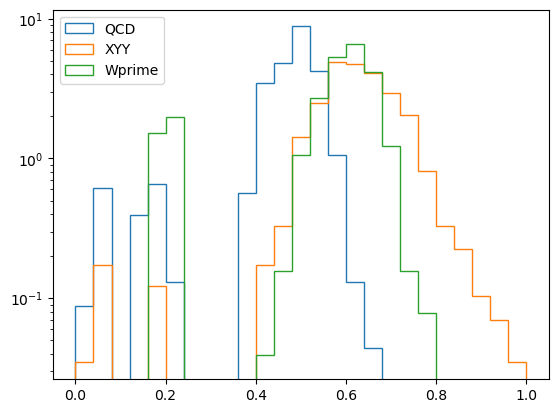

In [104]:
plt.hist(ab,bins=np.arange(0,1.04,0.04),histtype='step',density=True,label="QCD")
plt.hist(aX,bins=np.arange(0,1.04,0.04),histtype='step',density=True,label="XYY")
plt.hist(aW,bins=np.arange(0,1.04,0.04),histtype='step',density=True,label="Wprime")
plt.legend(loc='upper left')
plt.yscale('log')

In [99]:
# re-order background events
f_ref = h5py.File("/nobackup/users/sambt/CASE_samples/full_run2/newBB/BB/BB_batch_0.h5","r")
mref = f_ref['jet_kinematics'][:,0]
dEta_ref = f_ref['jet_kinematics'][:,1]
cut = (mref>2700) & (mref<3300) & (dEta_ref < 1.3)
mref = mref[cut]
bkg_reindex = np.array([list(mb).index(mri) for mri in mref])
np.all(mb[bkg_reindex] == mref)
f_ref.close()

In [100]:
np.savez("anomalyScores_forOz/bkg.npz",mjj=mb[bkg_reindex],scores=ab[bkg_reindex])
np.savez("anomalyScores_forOz/XYY.npz",mjj=mx,scores=aX)
np.savez("anomalyScores_forOz/Wprime.npz",mjj=mW,scores=aW)

In [4]:
b = np.load("anomalyScores_2/bkg.npz")
x = np.load("anomalyScores_2/XYY.npz")
w = np.load("anomalyScores_2/Wprime.npz")

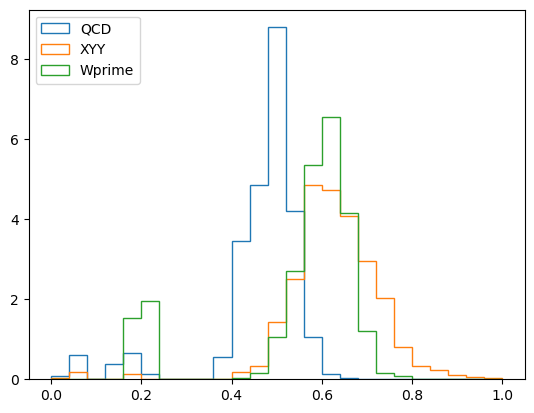

In [8]:
plt.hist(b['scores'],bins=np.arange(0,1.04,0.04),histtype='step',density=True,label="QCD")
plt.hist(x['scores'],bins=np.arange(0,1.04,0.04),histtype='step',density=True,label="XYY")
plt.hist(w['scores'],bins=np.arange(0,1.04,0.04),histtype='step',density=True,label="Wprime")
plt.legend(loc='upper left')
#plt.yscale('log')